# Jacobian unit-test figures — Test Case E

Figures for **Test Case E** of `tests/test_jacobian.py`
(`test_jacobian_output_coordinate_contract`).

**Idea.** Independent of rotation, all four outputs must live on
tracer points (`face, j, i`), drop the staggered `i_g`/`j_g` axes,
and preserve the per-face `(n, n)` shape. This pins the coordinate
contract the rest of the pipeline relies on.

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We import the test module itself so
# the figures are generated from the very same fixtures, parameters and
# assertions used by tests/test_jacobian.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import dbof.utils.native_gradient as ng

# Make the repository's tests/ importable, then reuse its code.
_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('EDGE_MARGIN =', tj.EDGE_MARGIN, '| N_FACES =', tj.N_FACES)


EDGE_MARGIN = 3 | N_FACES = 13


## 1. Run with a generic rotation and inspect the outputs

We use a non-special 33° rotation so the contract is not tied to
any particular angle.

In [2]:
d = 2500.0
n = 16
alpha = np.radians(33.0)
ds, grid = tj.make_synthetic_grid(n=n, d=d,
                                  cs=np.cos(alpha), sn=np.sin(alpha))
u_x, v_y = tj.add_linear_velocity(ds, d, 1.0e-5, 2.0e-5, -3.0e-5, 4.0e-5)
outs = ng.calculate_jacobian(u_x, v_y, ds, grid)
names = ['du_lambda_dlambda', 'du_lambda_dphi',
         'dv_phi_dlambda', 'dv_phi_dphi']

print('Inputs:')
print(f'  U dims={u_x.dims} shape={u_x.shape}')
print(f'  V dims={v_y.dims} shape={v_y.shape}')
print('Outputs:')
for nm, o in zip(names, outs):
    print(f'  {nm:18s} dims={o.dims} shape={o.shape}')


Inputs:
  U dims=('face', 'j', 'i_g') shape=(13, 16, 16)
  V dims=('face', 'j_g', 'i') shape=(13, 16, 16)
Outputs:
  du_lambda_dlambda  dims=('face', 'j', 'i') shape=(13, 16, 16)
  du_lambda_dphi     dims=('face', 'j', 'i') shape=(13, 16, 16)
  dv_phi_dlambda     dims=('face', 'j', 'i') shape=(13, 16, 16)
  dv_phi_dphi        dims=('face', 'j', 'i') shape=(13, 16, 16)


## 2. Staggering collapses to tracer points

The inputs sit on staggered velocity axes (`i_g` for U, `j_g` for
V); every output sits on the tracer centre axes (`i`, `j`). The
bar chart shows each output dimension's length equals `n` (or
`N_FACES` for `face`), and the table confirms `i_g`/`j_g` are gone.

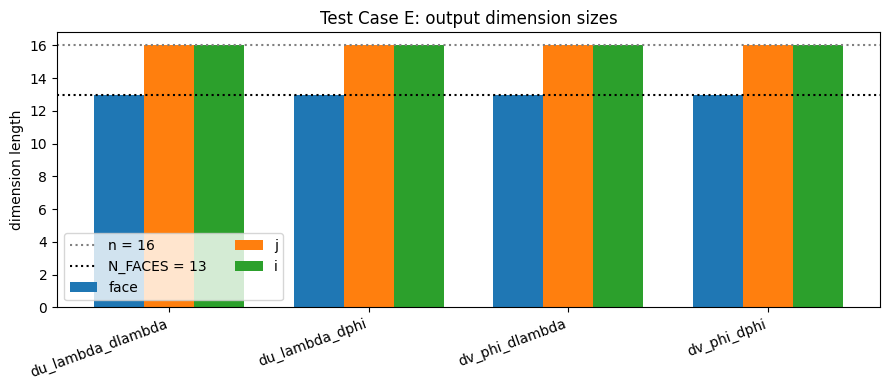

  du_lambda_dlambda  OK: on (face, j, i), no staggered axes
  du_lambda_dphi     OK: on (face, j, i), no staggered axes
  dv_phi_dlambda     OK: on (face, j, i), no staggered axes
  dv_phi_dphi        OK: on (face, j, i), no staggered axes


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
dims = ['face', 'j', 'i']
x = np.arange(len(names))
width = 0.25
for k, dim in enumerate(dims):
    sizes = [o.sizes[dim] for o in outs]
    ax.bar(x + (k - 1) * width, sizes, width, label=dim)
ax.axhline(n, color='grey', ls=':', label=f'n = {n}')
ax.axhline(tj.N_FACES, color='k', ls=':', label=f'N_FACES = {tj.N_FACES}')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('dimension length')
ax.set_title('Test Case E: output dimension sizes')
ax.legend(ncol=2); fig.tight_layout(); plt.show()

# Explicit contract checks, mirroring the assertions in the test.
for nm, o in zip(names, outs):
    assert 'i_g' not in o.dims and 'j_g' not in o.dims
    assert {'face', 'j', 'i'}.issubset(o.dims)
    print(f'  {nm:18s} OK: on (face, j, i), no staggered axes')


## 3. The output really is a full `(face, j, i)` field

A quick imshow of one component on one face confirms a populated
`n x n` tracer-grid array (not collapsed or transposed).

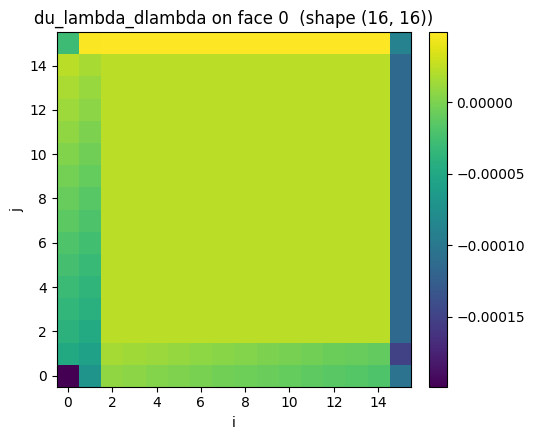

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
pcm = ax.imshow(outs[0].isel(face=0).values, origin='lower', cmap='viridis')
fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('%s on face 0  (shape %s)'
             % (names[0], outs[0].isel(face=0).shape))
ax.set_xlabel('i'); ax.set_ylabel('j')
fig.tight_layout(); plt.show()


## 4. Run the actual unit test

No exception means Test Case E passes.

In [5]:
tj.test_jacobian_output_coordinate_contract()
print('Test Case E passed.')


Test Case E passed.
